# GTCRN — Finetune 20 epoch trên dữ liệu tiếng Việt + Infer trên tập TEST

Repo gốc (`Xiaobin-Rong/gtcrn`) **không có sẵn `train.py`** — chỉ có kiến trúc model (`gtcrn.py`), hàm loss (`loss.py`) và demo infer 1 file. Notebook này tự viết Dataset + training loop, warm-start từ checkpoint pretrained `model_trained_on_dns3.tar`, finetune 20 epoch, rồi infer trên `TEST`.

Chạy tuần tự (Run All):
1. Clone repo + cài thư viện
2. Ghép cặp CLEAN ↔ NOISE (mix sẵn) theo tên file, chia train/val
3. Dataset/DataLoader (crop/pad về đoạn 4 giây, 16kHz mono)
4. Nạp checkpoint pretrained để warm-start (hoặc tự resume nếu đã finetune dở từ trước)
5. Train 20 epoch, theo dõi val loss, lưu `best.tar`
6. Vẽ biểu đồ train/val loss để kiểm tra overfitting
7. Infer toàn bộ `TEST` bằng checkpoint tốt nhất
8. Nén checkpoint + kết quả infer để tải về

In [1]:
# ==== BƯỚC 1: Clone repo + cài thư viện ====
%cd /kaggle/working
!rm -rf gtcrn
!git clone https://github.com/Xiaobin-Rong/gtcrn.git
%cd gtcrn
!pip install -q einops soundfile tqdm matplotlib

/kaggle/working
Cloning into 'gtcrn'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 361 (delta 90), reused 65 (delta 65), pack-reused 254 (from 1)
Receiving objects: 100% (361/361), 10.84 MiB | 19.20 MiB/s, done.
Resolving deltas: 100% (163/163), done.
/kaggle/working/gtcrn


In [2]:
# ==== BƯỚC 2: Cấu hình đường dẫn & tham số ====
import os, glob

CLEAN_DIR = "/kaggle/input/datasets/khabiphmhng/noise-speech/NOISE SPEECH/TRAIN/CLEAN"
NOISE_DIR = "/kaggle/input/datasets/khabiphmhng/noise-speech/NOISE SPEECH/TRAIN/NOISE"  # da mix san
TEST_DIR  = "/kaggle/input/datasets/khabiphmhng/noise-speech/NOISE SPEECH/TEST "

WORK_DIR    = "/kaggle/working/gtcrn_finetune"
CKPT_DIR    = os.path.join(WORK_DIR, "checkpoints")
INFER_DIR   = "/kaggle/working/generated_files/gtcrn_finetuned_output"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)

# Checkpoint pretrained co san trong repo, dung de warm-start neu chua finetune lan nao
PRETRAINED_CKPT = "checkpoints/model_trained_on_dns3.tar"  # doi sang model_trained_on_vctk.tar neu muon

TARGET_SR   = 16000
CHUNK_SEC   = 4
CHUNK_LEN   = TARGET_SR * CHUNK_SEC
BATCH_SIZE  = 16          # GTCRN cuc nhe (23K params) nen batch lon van thoai mai tren T4
NUM_EPOCHS  = 20
LR          = 1e-4        # nho hon lr goc vi la finetune, khong phai train tu dau
VAL_RATIO   = 0.05

for d in [CLEAN_DIR, NOISE_DIR, TEST_DIR]:
    assert os.path.isdir(d), f"Khong tim thay thu muc: {d}"
print("Cau hinh san sang.")

Cau hinh san sang.


In [3]:
# ==== BƯỚC 3: Ghép cặp CLEAN <-> NOISE theo tên file, chia train/val ====
import random

AUDIO_EXT = (".wav", ".flac")

def list_audio(folder):
    return {f for f in os.listdir(folder) if f.lower().endswith(AUDIO_EXT)}

clean_names = list_audio(CLEAN_DIR)
noise_names = list_audio(NOISE_DIR)
common = sorted(clean_names & noise_names)

print(f"CLEAN: {len(clean_names)} | NOISE(mix): {len(noise_names)} | Khop ten ca 2: {len(common)}")
assert len(common) > 0, "Khong tim thay file nao trung ten giua CLEAN va NOISE!"

random.seed(1234)
shuffled = common[:]
random.shuffle(shuffled)
val_size = max(1, int(len(shuffled) * VAL_RATIO))
val_names = shuffled[:val_size]
train_names = shuffled[val_size:]

print(f"Train: {len(train_names)} | Val: {len(val_names)}")

CLEAN: 8460 | NOISE(mix): 8460 | Khop ten ca 2: 8460
Train: 8037 | Val: 423


In [4]:
# ==== BƯỚC 4: Dataset + DataLoader ====
import numpy as np
import soundfile as sf
import torch
from torch.utils.data import Dataset, DataLoader

def load_mono_16k(path, target_sr=TARGET_SR):
    wav, sr = sf.read(path, dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != target_sr:
        import librosa
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
    return wav.astype(np.float32)

class DenoiseDataset(Dataset):
    def __init__(self, names, clean_dir, noise_dir, chunk_len=CHUNK_LEN, train=True):
        self.names = names
        self.clean_dir = clean_dir
        self.noise_dir = noise_dir
        self.chunk_len = chunk_len
        self.train = train

    def __len__(self):
        return len(self.names)

    def _crop_or_pad(self, x):
        n = self.chunk_len
        if len(x) >= n:
            if self.train:
                start = random.randint(0, len(x) - n)
            else:
                start = 0  # validation: luon lay doan dau cho on dinh
            return x[start:start + n]
        return np.pad(x, (0, n - len(x)))

    def __getitem__(self, idx):
        name = self.names[idx]
        clean = load_mono_16k(os.path.join(self.clean_dir, name))
        mix   = load_mono_16k(os.path.join(self.noise_dir, name))
        n = min(len(clean), len(mix))
        clean, mix = clean[:n], mix[:n]

        if self.train:
            start = 0 if n <= self.chunk_len else random.randint(0, n - self.chunk_len)
            clean = clean[start:start + self.chunk_len] if n > self.chunk_len else np.pad(clean, (0, self.chunk_len - n))
            mix   = mix[start:start + self.chunk_len]   if n > self.chunk_len else np.pad(mix,   (0, self.chunk_len - n))
        else:
            clean = clean[:self.chunk_len] if n >= self.chunk_len else np.pad(clean, (0, self.chunk_len - n))
            mix   = mix[:self.chunk_len]   if n >= self.chunk_len else np.pad(mix,   (0, self.chunk_len - n))

        return torch.from_numpy(mix), torch.from_numpy(clean)

train_ds = DenoiseDataset(train_names, CLEAN_DIR, NOISE_DIR, train=True)
val_ds   = DenoiseDataset(val_names,   CLEAN_DIR, NOISE_DIR, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)

print(f"Steps/epoch (train): {len(train_loader)} | Steps (val): {len(val_loader)}")

Steps/epoch (train): 502 | Steps (val): 27


In [5]:
# ==== BƯỚC 5: Nạp model — warm-start tu pretrained hoac tu resume neu da finetune dang do ====
import sys
sys.path.insert(0, "/kaggle/working/gtcrn")
from gtcrn import GTCRN
from loss import HybridLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = GTCRN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = HybridLoss()

last_ckpt_path = os.path.join(CKPT_DIR, "last.tar")
start_epoch = 0

if os.path.isfile(last_ckpt_path):
    print(f"Tim thay checkpoint finetune do dang: {last_ckpt_path} -> resume.")
    ckpt = torch.load(last_ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt["epoch"] + 1
    print(f"Resume tu epoch {start_epoch}.")
else:
    print(f"Chua co checkpoint finetune -> warm-start tu pretrained: {PRETRAINED_CKPT}")
    ckpt = torch.load(PRETRAINED_CKPT, map_location=device)
    model.load_state_dict(ckpt["model"])

TARGET_EPOCH = start_epoch + NUM_EPOCHS  # luon finetune THEM dung NUM_EPOCHS epoch tinh tu diem hien tai
print(f"Se train tu epoch {start_epoch} den epoch {TARGET_EPOCH - 1} (tong them {NUM_EPOCHS} epoch).")

Device: cuda
Chua co checkpoint finetune -> warm-start tu pretrained: checkpoints/model_trained_on_dns3.tar
Se train tu epoch 0 den epoch 19 (tong them 20 epoch).


In [6]:
# ==== BƯỚC 6: Vong lap finetune ====
from tqdm.auto import tqdm

win = torch.hann_window(512).pow(0.5).to(device)

def to_spec(x):
    # x: (B, T) float32 waveform -> (B, F, T', 2)
    return torch.stft(x, 512, 256, 512, win, return_complex=False)

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss, n_batches = 0.0, 0
    with torch.set_grad_enabled(train_mode):
        for mix, clean in loader:
            mix, clean = mix.to(device), clean.to(device)
            mix_spec, clean_spec = to_spec(mix), to_spec(clean)
            pred_spec = model(mix_spec)
            loss = loss_fn(pred_spec, clean_spec)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(1, n_batches)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_ckpt_path = os.path.join(CKPT_DIR, "best.tar")

if os.path.isfile(os.path.join(CKPT_DIR, "history.npy")):
    prev = np.load(os.path.join(CKPT_DIR, "history.npy"), allow_pickle=True).item()
    history = prev.get("history", history)
    best_val_loss = prev.get("best_val_loss", best_val_loss)

for epoch in tqdm(range(start_epoch, TARGET_EPOCH), desc="Epochs"):
    train_loss = run_epoch(train_loader, train_mode=True)
    val_loss = run_epoch(val_loader, train_mode=False)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # Luon luu 'last' de co the resume neu bi ngat giua chung
    torch.save({"epoch": epoch, "model": model.state_dict(), "optimizer": optimizer.state_dict()}, last_ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({"epoch": epoch, "model": model.state_dict(), "optimizer": optimizer.state_dict()}, best_ckpt_path)
        print(f"  -> Val loss cai thien, luu best.tar (epoch {epoch}, val_loss={val_loss:.4f})")

    np.save(os.path.join(CKPT_DIR, "history.npy"), {"history": history, "best_val_loss": best_val_loss})

print("Finetune hoan tat.")
print(f"Best checkpoint: {best_ckpt_path} (val_loss={best_val_loss:.4f})")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:874.)
  return _VF.stft(  # type: ignore[attr-defined]


Epoch 0: train_loss=3.0143 | val_loss=2.8147
  -> Val loss cai thien, luu best.tar (epoch 0, val_loss=2.8147)
Epoch 1: train_loss=2.8457 | val_loss=2.7145
  -> Val loss cai thien, luu best.tar (epoch 1, val_loss=2.7145)
Epoch 2: train_loss=2.7970 | val_loss=2.6607
  -> Val loss cai thien, luu best.tar (epoch 2, val_loss=2.6607)
Epoch 3: train_loss=2.7539 | val_loss=2.6380
  -> Val loss cai thien, luu best.tar (epoch 3, val_loss=2.6380)
Epoch 4: train_loss=2.7168 | val_loss=2.6139
  -> Val loss cai thien, luu best.tar (epoch 4, val_loss=2.6139)
Epoch 5: train_loss=2.6999 | val_loss=2.5980
  -> Val loss cai thien, luu best.tar (epoch 5, val_loss=2.5980)
Epoch 6: train_loss=2.6829 | val_loss=2.5813
  -> Val loss cai thien, luu best.tar (epoch 6, val_loss=2.5813)
Epoch 7: train_loss=2.6640 | val_loss=2.5668
  -> Val loss cai thien, luu best.tar (epoch 7, val_loss=2.5668)
Epoch 8: train_loss=2.6470 | val_loss=2.5519
  -> Val loss cai thien, luu best.tar (epoch 8, val_loss=2.5519)
Epoch 9: t

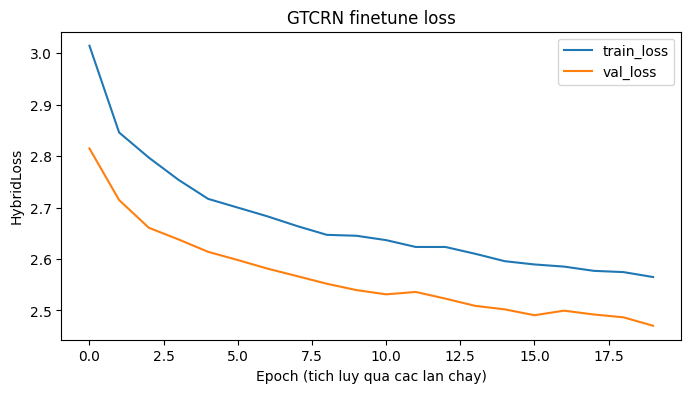

In [7]:
# ==== BƯỚC 7: Bieu do train/val loss (kiem tra overfitting) ====
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch (tich luy qua cac lan chay)")
plt.ylabel("HybridLoss")
plt.legend()
plt.title("GTCRN finetune loss")
plt.savefig(os.path.join(CKPT_DIR, "loss_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

In [8]:
# ==== BƯỚC 8: Infer tren tap TEST bang checkpoint tot nhat vua finetune ====
infer_model = GTCRN().to(device).eval()
best_ckpt = torch.load(best_ckpt_path, map_location=device)
infer_model.load_state_dict(best_ckpt["model"])
print(f"Dung best.tar (epoch {best_ckpt['epoch']}) de infer.")

test_files = sorted(f for f in os.listdir(TEST_DIR) if f.lower().endswith(".wav"))
print(f"So file TEST: {len(test_files)}")

with torch.no_grad():
    for fname in test_files:
        wav = load_mono_16k(os.path.join(TEST_DIR, fname))
        x = torch.from_numpy(wav).to(device)
        spec = torch.stft(x[None], 512, 256, 512, win, return_complex=False)
        pred_spec = infer_model(spec)[0]
        enh = torch.istft(torch.view_as_complex(pred_spec.contiguous()), 512, 256, 512, win)
        sf.write(os.path.join(INFER_DIR, fname), enh.detach().cpu().numpy(), TARGET_SR)

print(f"Da infer xong {len(test_files)} file, luu tai: {INFER_DIR}")

Dung best.tar (epoch 19) de infer.
So file TEST: 940
Da infer xong 940 file, luu tai: /kaggle/working/generated_files/gtcrn_finetuned_output


In [9]:
# ==== BƯỚC 9: Nen checkpoint + ket qua infer de tai ve ====
import shutil

shutil.make_archive("/kaggle/working/gtcrn_finetune_checkpoints", "zip", CKPT_DIR)
shutil.make_archive("/kaggle/working/gtcrn_finetuned_test_output", "zip", INFER_DIR)

print("Da tao file zip (vao tab Output de tai):")
print(" - /kaggle/working/gtcrn_finetune_checkpoints.zip")
print(" - /kaggle/working/gtcrn_finetuned_test_output.zip")

Da tao file zip (vao tab Output de tai):
 - /kaggle/working/gtcrn_finetune_checkpoints.zip
 - /kaggle/working/gtcrn_finetuned_test_output.zip
